# **Master's Thesis Source Code (2026)**
### Name: Sagar Kumar
### Matriculation No.: 30000402
### Programme: Data Science for Society and Business
### Semester: Summer 2026
### First Supervisor: Prof. Dr. Jan Lorenz
### Second Supervisor: Prof. Dr. Adalbert Wilhelm

## **Index**

#### **1. Yelp Data Analysis**
##### 1.1 Import and Clean Data
##### 1.2 Data Exploration
##### 1.3 Relationship between Ratings and Demand
##### 1.4 Sentiment Analysis
##### 1.5 OLS Regression Analysis
##### 1.6 Machine Learning Predictions

#### **2. Amazon Data Analysis**
##### 2.1 Import and Clean Data
##### 2.2 Data Exploration
##### 2.3 Relationship between Ratings and Demand
##### 2.4 Sentiment Analysis
##### 2.5 OLS Regression Analysis
##### 2.6 Machine Learning Predictions

# **1. Yelp Dataset Analysis**
#### 1.1 Import and Clean Data

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [62]:
# import business data
yelp_business = pd.read_json("data/yelp_academic_dataset_business_subset.json", lines=True)
yelp_business = yelp_business[["business_id","name","city","state", "stars","review_count","attributes","categories"]] # extract only relevant columns
yelp_business.head(3)

,business_id,name,city,state,stars,review_count,attributes,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ",Santa Barbara,CA,5.0,7,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,Affton,MO,3.0,15,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,Tucson,AZ,3.5,22,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G..."


In [63]:
# import reviews data
yelp_review = pd.read_json("data/yelp_academic_dataset_review_subset.json", lines=True)
yelp_review.head(3)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30


In [64]:
# merge review and business data based on business ID
df = yelp_review.merge(
    yelp_business,
    on="business_id",
    how="inner"
)

# rename x/y columns appropriately
df = df.rename(columns={
    "stars_x": "stars",
    "stars_y": "business_stars"
})

df.head(3)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,city,state,business_stars,review_count,attributes,categories
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,North Wales,PA,3.0,169,"{'NoiseLevel': 'u'average'', 'HasTV': 'False',...","Restaurants, Breakfast & Brunch, Food, Juice B..."
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,Philadelphia,PA,5.0,144,"{'BusinessAcceptsCreditCards': 'True', 'GoodFo...","Active Life, Cycling Classes, Trainers, Gyms, ..."
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Kettle Restaurant,Tucson,AZ,3.5,47,"{'RestaurantsReservations': 'True', 'BusinessP...","Restaurants, Breakfast & Brunch"


#### 1.2 Data Exploration

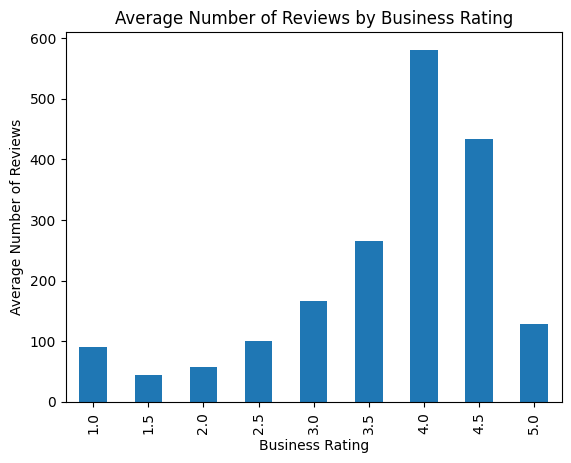

In [65]:
# Average Number of Reviews by Business Rating
avg_reviews = df.groupby("business_stars")["review_count"].mean()

plt.figure()
avg_reviews.plot(kind="bar")
plt.xlabel("Business Rating")
plt.ylabel("Average Number of Reviews")
plt.title("Average Number of Reviews by Business Rating")
plt.show()

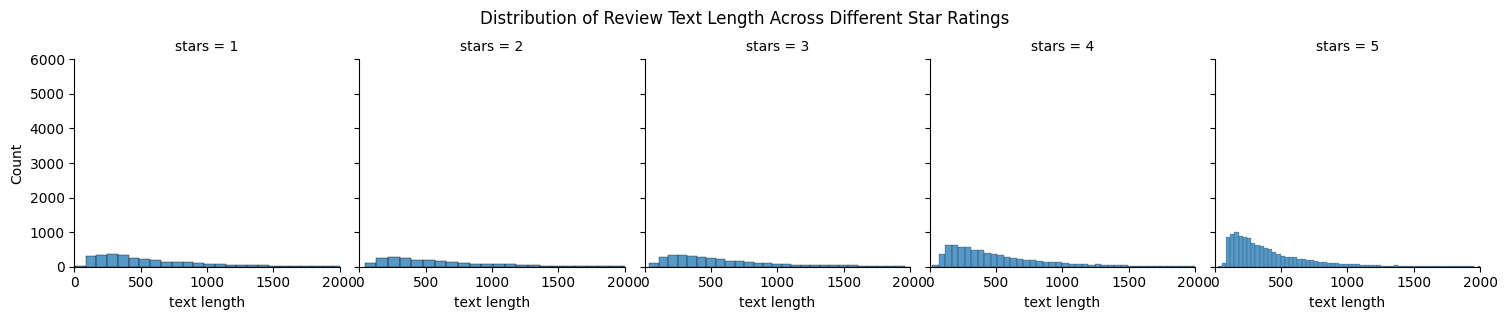

In [66]:
# Distribution of Review Text Length by Star Rating
df['text'] = df['text'].str.lower()
df['text'] = df['text'].str.replace('[^\w\s]', '')
df['text'] = df['text'].str.replace('\d', '')
df['text length'] = df['text'].apply(len)

g = sns.FacetGrid(data=df, col='stars')
g.map(sns.histplot, 'text length')

# set x-axis max limit
g.set(xlim=(0, 2000),ylim=(0,6000))
g.fig.suptitle("Distribution of Review Text Length Across Different Star Ratings", y=1.05)
plt.show()

#### 1.3 Relationship between Ratings and Demand

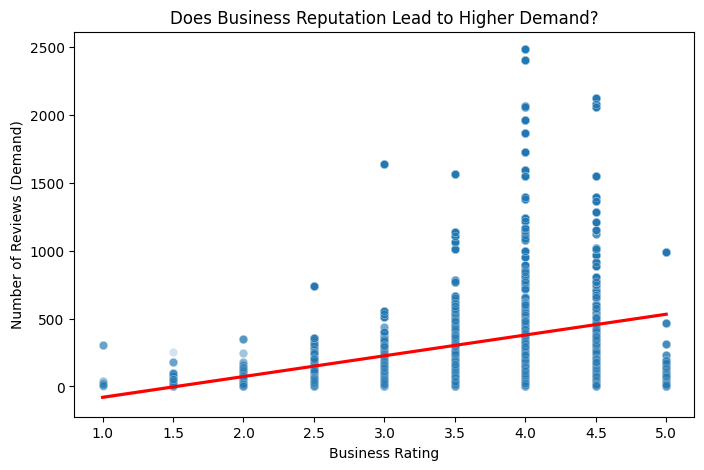

In [67]:
# remove outliers
df_clean = df[df["review_count"] < df["review_count"].quantile(0.99)]
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="business_stars",
    y="review_count",
    alpha=0.1
)

# regression line
sns.regplot(
    data=df_clean,
    x="business_stars",
    y="review_count",
    scatter=False,
    color="red"
)

plt.xlabel("Business Rating")
plt.ylabel("Number of Reviews (Demand)")
plt.title("Does Business Reputation Lead to Higher Demand?")
plt.show()

#### 1.4 Sentiment Analysis

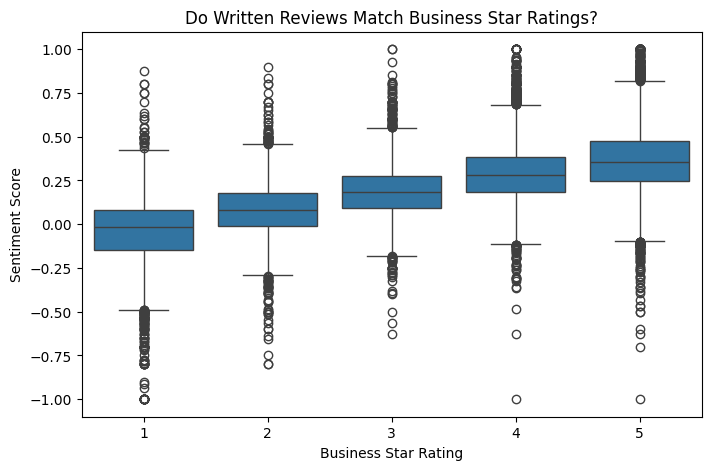

In [68]:
# calculate sentiment score for each review
df["sentiment"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stars",
    y="sentiment"
)
plt.xlabel("Business Star Rating")
plt.ylabel("Sentiment Score")
plt.title("Do Written Reviews Match Business Star Ratings?")
plt.show()

#### 1.5 OLS Regression Analysis

In [69]:
df = df.dropna(subset=["text", "business_stars", "review_count"]).copy()

# feature "review length"
df["review_length"] = df["text"].apply(len)

# log-transform to reduce effect of skewness and outliers
df["log_reviews"] = np.log1p(df["review_count"])

# indepdendant variables: business_stars, sentiment, review_length
# depandant variable: log_reviews
X = df[["business_stars", "sentiment", "review_length"]]
y = df["log_reviews"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_reviews   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     777.6
Date:                Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                        22:32:39   Log-Likelihood:                -51690.
No. Observations:               30000   AIC:                         1.034e+05
Df Residuals:                   29996   BIC:                         1.034e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.9968      0.046     64.

#### 1.6 Machine Learning Predictions

In [70]:
# Goal: Predict business demand (review count) using ratings, sentiment, review length, and location-based features
# add city and state as feature to improve predictions
df["city_encoded"] = df["city"].astype("category").cat.codes
df["state_encoded"] = df["state"].astype("category").cat.codes

# features
X = df[["business_stars", "sentiment", "review_length", "city_encoded","state_encoded"]]
y = df["log_reviews"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# convert back to real scale from logarithmic
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

# calculate root mean squared error
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
print("Random Forest RMSE:", rmse)

Random Forest RMSE: 585.0881337771677


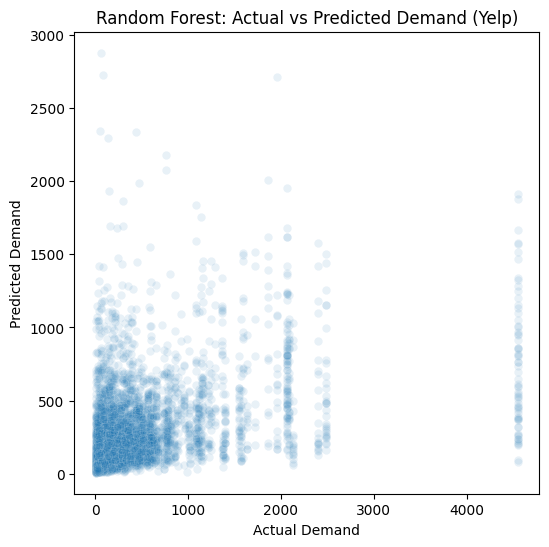

In [71]:
# plot actual vs predicted demand values
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test_real,
    y=y_pred_real,
    alpha=0.1
)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Random Forest: Actual vs Predicted Demand (Yelp)")
plt.show()


Feature Importance:
sentiment         0.286679
review_length     0.278890
city_encoded      0.202774
business_stars    0.171853
state_encoded     0.059804
dtype: float64


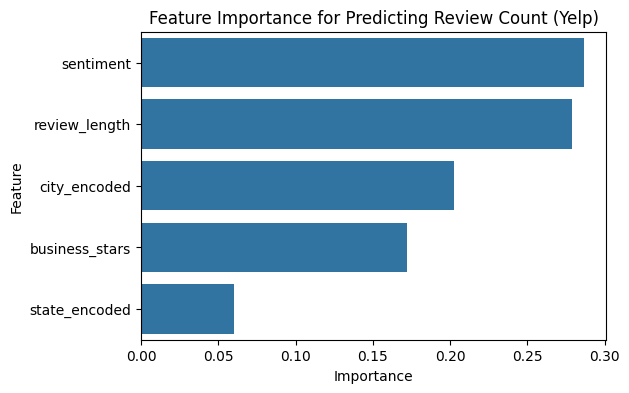

In [72]:
# Goal: Analyze which features contribute most to predicting business demand (review count)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nFeature Importance:")
print(importances)

plt.figure(figsize=(6,4))
sns.barplot(
    x=importances.values,
    y=importances.index
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Predicting Review Count (Yelp)")
plt.show()

# **2. Amazon Dataset Analysis**

#### 2.1 Import and Clean Data

In [73]:
# import amazon data
df_review = pd.read_json("data/amazon_Electronics_subset.json", lines=True)
df_review.head(3)

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5,True,"07 17, 2002",A1N070NS9CJQ2I,0060009810,{'Format:': ' Hardcover'},Teri Adams,This was the first time I read Garcia-Aguilera...,Hit The Spot!,1026864000,None,None
1,5,False,"07 6, 2002",A3P0KRKOBQK1KN,0060009810,{'Format:': ' Hardcover'},Willa C.,"As with all of Ms. Garcia-Aguilera's books, I ...",one hot summer is HOT HOT HOT!,1025913600,None,None
2,5,False,"07 3, 2002",A192HO2ICJ75VU,0060009810,{'Format:': ' Hardcover'},Kit,I've not read any of Ms Aguilera's works befor...,One Hot Summer,1025654400,2,None


In [74]:
# import meta data for products
df_meta = pd.read_json("data/amazon_Electronics_metadata_subset.json", lines=True, nrows=2500)
df_meta.head(3)

,category,tech1,description,fit,title,also_buy,tech2,brand,feature,rank,also_view,main_cat,similar_item,date,price,asin,imageURL,imageURLHighRes,details
0,"[Electronics, Camera &amp; Photo, Video Survei...",,[The following camera brands and models have b...,,Genuine Geovision 1 Channel 3rd Party NVR IP S...,[],,GeoVision,"[Genuine Geovision 1 Channel NVR IP Software, ...","[>#3,092 in Tools &amp; Home Improvement &gt; ...",[],Camera &amp; Photo,,"January 28, 2014",$65.00,0011300000,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...,None
1,"[Electronics, Camera &amp; Photo]",,[This second edition of the Handbook of Astron...,,"Books ""Handbook of Astronomical Image Processi...",[0999470906],,33 Books Co.,[Detailed chapters cover these fundamental top...,"[>#55,933 in Camera &amp; Photo (See Top 100 i...","[0943396670, 1138055360, 0999470906]",Camera &amp; Photo,,"June 17, 2003",,0043396828,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...,None
2,"[Electronics, eBook Readers &amp; Accessories,...",,[A zesty tale. (Publishers Weekly)<br /><br />...,,One Hot Summer,"[0425167798, 039914157X]",,Visit Amazon's Carolina Garcia Aguilera Page,[],"3,105,177 in Books (",[],Books,,,$11.49,0060009810,[],[],None


In [75]:
# merge product data and metadata based on ASIN (product ID)
df = df_review.merge(df_meta, on="asin", how="left")

# rename columns appropriately
df = df.rename(columns={
    "overall": "stars",
    "reviewText": "text"
})
df.head(3)

,stars,verified,reviewTime,reviewerID,asin,style,reviewerName,text,summary,unixReviewTime,...,feature,rank,also_view,main_cat,similar_item,date,price,imageURL,imageURLHighRes,details
0,5,True,"07 17, 2002",A1N070NS9CJQ2I,0060009810,{'Format:': ' Hardcover'},Teri Adams,This was the first time I read Garcia-Aguilera...,Hit The Spot!,1026864000,...,[],"3,105,177 in Books (",[],Books,,,$11.49,[],[],None
1,5,False,"07 6, 2002",A3P0KRKOBQK1KN,0060009810,{'Format:': ' Hardcover'},Willa C.,"As with all of Ms. Garcia-Aguilera's books, I ...",one hot summer is HOT HOT HOT!,1025913600,...,[],"3,105,177 in Books (",[],Books,,,$11.49,[],[],None
2,5,False,"07 3, 2002",A192HO2ICJ75VU,0060009810,{'Format:': ' Hardcover'},Kit,I've not read any of Ms Aguilera's works befor...,One Hot Summer,1025654400,...,[],"3,105,177 in Books (",[],Books,,,$11.49,[],[],None


#### 2.2 Data Exploration

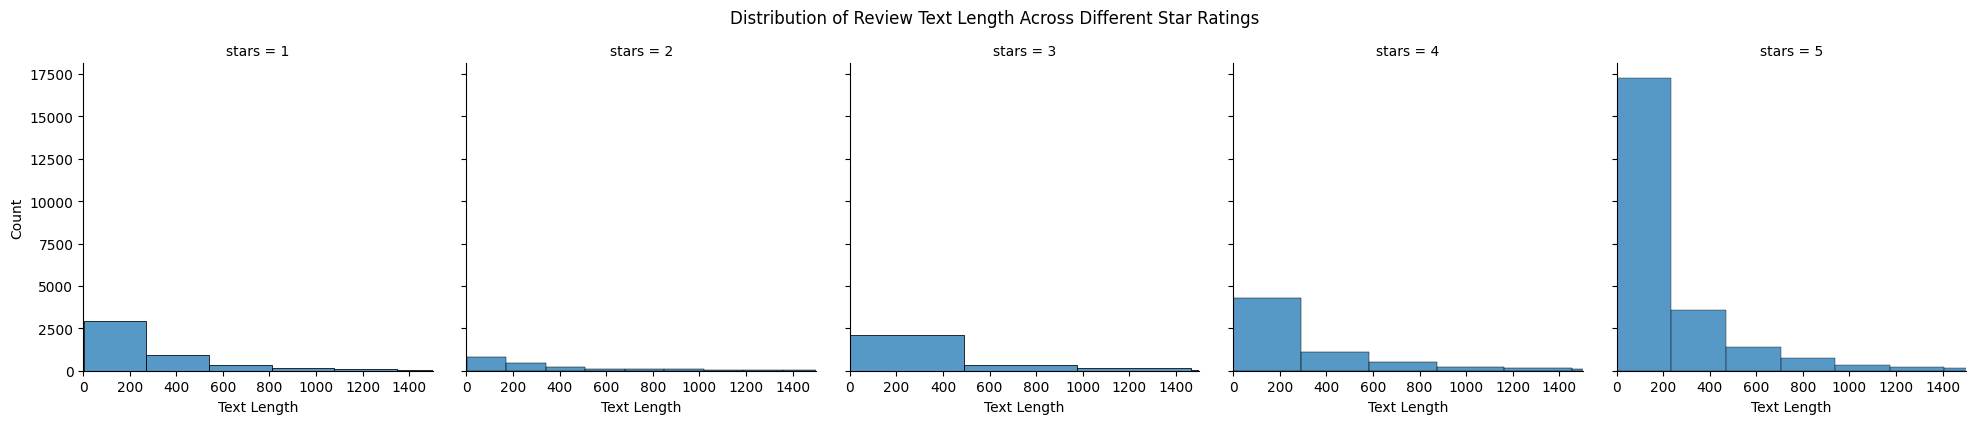

In [76]:
# Review Text Length Distribution by Product Rating
df["text_length"] = df["text"].astype(str).apply(len)

g = sns.FacetGrid(df, col="stars", col_wrap=5, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "text_length", bins=40)

# set max x value 
g.set(xlim=(0, 1500))
g.set_axis_labels("Text Length", "Count")
g.set_titles("stars = {col_name}")
g.fig.suptitle("Distribution of Review Text Length Across Different Star Ratings", y=1.05)

plt.show()

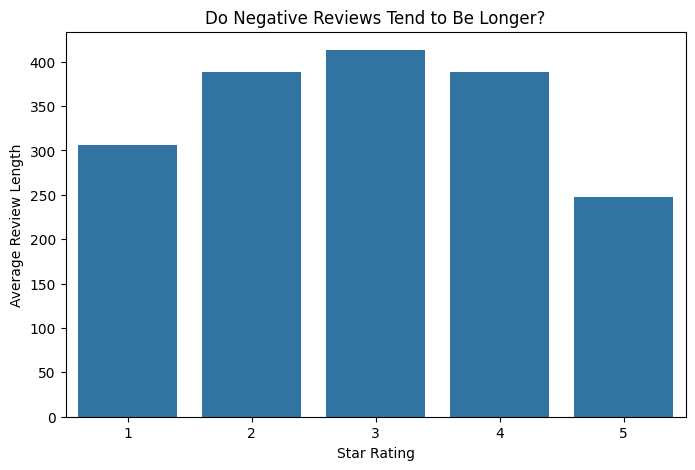

In [77]:
# Average Review Length by Product Rating
df["text_length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="stars",
    y="text_length",
    estimator="mean",
    errorbar=None
)

plt.xlabel("Star Rating")
plt.ylabel("Average Review Length")
plt.title("Do Negative Reviews Tend to Be Longer?")
plt.show()

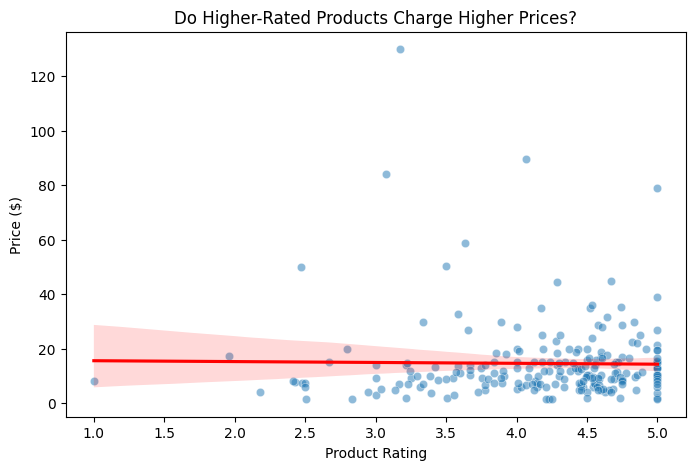

In [85]:
# Product Rating vs. Price
# convert price to numeric
df["price"] = (df["price"].replace('[\$,]', '', regex=True))
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# create product-level dataframe
df_price = df.groupby("asin").agg({
    "stars": "mean",
    "price": "mean"
}).reset_index()

# rename columns
df_price = df_price.rename(columns={
    "stars": "product_rating"
})

df_price = df_price.dropna(subset=["price", "product_rating"])
df_price = df_price[df_price["price"] <= 200]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_price,
    x="product_rating",
    y="price",
    alpha=0.5
)

# regression line
sns.regplot(
    data=df_price,
    x="product_rating",
    y="price",
    scatter=False,
    color="red"
)

plt.xlabel("Product Rating")
plt.ylabel("Price ($)")
plt.title("Do Higher-Rated Products Charge Higher Prices?")
plt.show()

#### 2.3 Relationship between Ratings and Demand

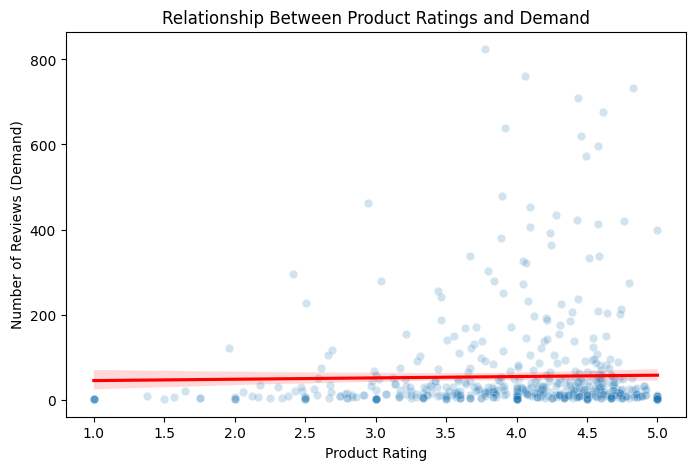

In [79]:
# create product-level dataframe for regression
df_product = df.groupby("asin").agg({
    "stars": "mean",
    "text": "count",
    "text_length": "mean",
}).reset_index()

# rename columns
df_product = df_product.rename(columns={
    "text": "review_count",
    "stars": "product_rating"
})

# remove extreme outliers
df_clean = df_product[
    df_product["review_count"] < df_product["review_count"].quantile(0.99)
]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_clean,
    x="product_rating",
    y="review_count",
    alpha=0.2
)

# regression line
sns.regplot(
    data=df_clean,
    x="product_rating",
    y="review_count",
    scatter=False,
    color="red"
)

plt.xlabel("Product Rating")
plt.ylabel("Number of Reviews (Demand)")
plt.title("Relationship Between Product Ratings and Demand")


# convert price string to numeric value
df["price"] = df["price"].replace('[\$,]', '', regex=True)
df["price"] = pd.to_numeric(df["price"], errors='coerce')
plt.show()

#### 2.4 Sentiment Analysis

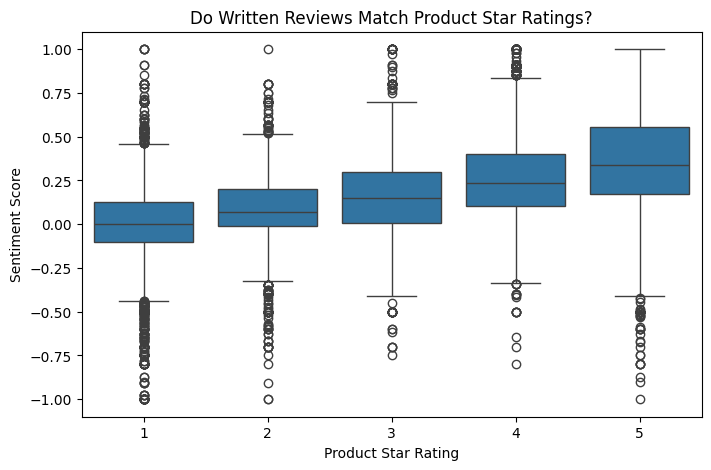

In [80]:
# ensure text is string
df["text"] = df["text"].astype(str)

# calculate sentiment score
df["sentiment"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="stars",
    y="sentiment"
)

plt.xlabel("Product Star Rating")
plt.ylabel("Sentiment Score")
plt.title("Do Written Reviews Match Product Star Ratings?")
plt.show()

#### 2.5 OLS Regression Analysis

In [81]:
df_product = df.groupby("asin").agg({
    "stars": "mean",
    "text": "count",
    "text_length": "mean",
    "sentiment": "mean"
}).reset_index()

df_product = df_product.rename(columns={
    "stars": "product_rating",
    "text": "review_count"
})

df_reg = df_product.dropna(
    subset=["product_rating", "review_count", "text_length", "sentiment"]
).copy()

# log-transform review count because demand is highly skewed
df_reg["log_review_count"] = np.log1p(df_reg["review_count"])

X = df_reg[["product_rating", "text_length", "sentiment"]]
X = sm.add_constant(X)
y = df_reg["log_review_count"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_review_count   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.620
Date:                Sun, 17 May 2026   Prob (F-statistic):             0.0500
Time:                        22:32:51   Log-Likelihood:                -1065.9
No. Observations:                 591   AIC:                             2140.
Df Residuals:                     587   BIC:                             2157.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.3200      0.334      9.

#### 2.6 Machine Learning Predictions

In [82]:
df_product = df_product.dropna(subset=["product_rating","review_count"]).copy()

# target variable
df_product["log_review_count"] = np.log1p(df_product["review_count"])

# features
X = df_product[["product_rating", "sentiment", "text_length"]]
y = df_product["log_review_count"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# convert log values back to normal review counts
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

# mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
print("Random Forest RMSE:", rmse)

Random Forest RMSE: 158.89701854228355


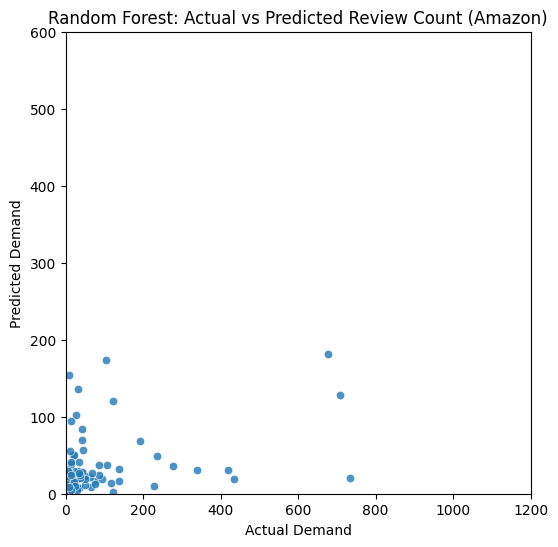

In [83]:
# plot
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test_real,
    y=y_pred_real,
    alpha=0.8
)
plt.xlim(0, 1200)
plt.ylim(0, 600)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Random Forest: Actual vs Predicted Review Count (Amazon)")
plt.show()


Feature Importance:
product_rating    0.443604
sentiment         0.291247
text_length       0.265149
dtype: float64


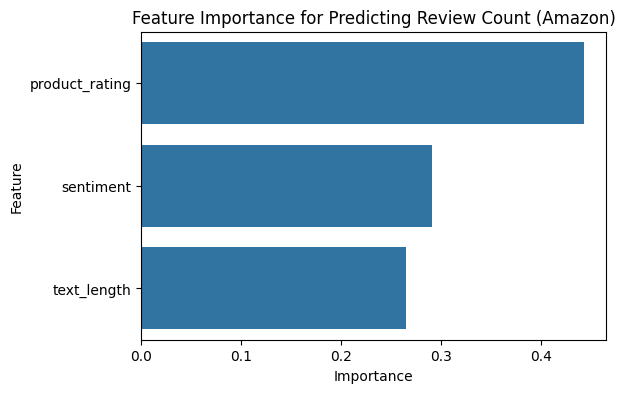

In [84]:
# Feature importance analysis
importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

print("\nFeature Importance:")
print(importances)

plt.figure(figsize=(6,4))
sns.barplot(
    x=importances.values,
    y=importances.index
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Predicting Review Count (Amazon)")
plt.show()